# Lab Session: Dimension Reduction and Latent Variables

Welcome to the lab session on Dimension Reduction and Latent Variables. In this session, we will explore Principal Component Analysis (PCA) and its advanced variants: Sparse PCA, Kernel PCA, and Probabilistic PCA (PPCA).

By the end of this lab, you will understand:
1. How PCA is used for dimension reduction, latent variable extraction, and representation.
2. Why standard PCA may fail to disentangle features, and how Sparse PCA addresses this in high-dimensional settings.
3. How Kernel PCA extends PCA to non-linear datasets where standard PCA fails.
4. The application of Probabilistic PCA (PPCA) in handling missing data and providing a generative framework.

You will also complete a coding exercise to test your understanding.

---

## Part 1: Standard PCA (Dimension Reduction, Latent Variables, and Representation)

Principal Component Analysis (PCA) is a foundational technique for unsupervised learning. It finds orthogonal directions (principal components) that maximize the variance of the projected data.

We will demonstrate PCA's three main uses:
- **Dimension Reduction:** Reducing the number of features while retaining most of the variance.
- **Latent Variable Extraction:** Discovering underlying hidden factors that explain the observed data.
- **Representation:** Reconstructing the original data from the reduced dimensions.

### 1.1 Setup and Data Generation

Let's generate a synthetic dataset where two latent variables drive the observed features.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Generate 2 latent variables (e.g., 'size' and 'shape')
n_samples = 300
latent_vars = np.random.randn(n_samples, 2)

# Create 5 observed features driven by the latent variables
# Features 1-3 are driven mostly by latent variable 1
# Features 4-5 are driven mostly by latent variable 2
W = np.array([
    [ 0.9,  0.1],
    [ 0.8,  0.2],
    [ 0.7, -0.1],
    [-0.2,  0.9],
    [ 0.1,  0.8]
])

# Observed data = Latent * W.T + noise
X = np.dot(latent_vars, W.T) + np.random.randn(n_samples, 5) * 0.5

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Original data shape: {X_scaled.shape}")

Original data shape: (300, 5)


### 1.2 Applying PCA

We will apply PCA to reduce the 5-dimensional data back to 2 dimensions.

Reduced data shape: (300, 2)
Explained variance ratio: [0.49254343 0.34304049]
Total explained variance: 0.84


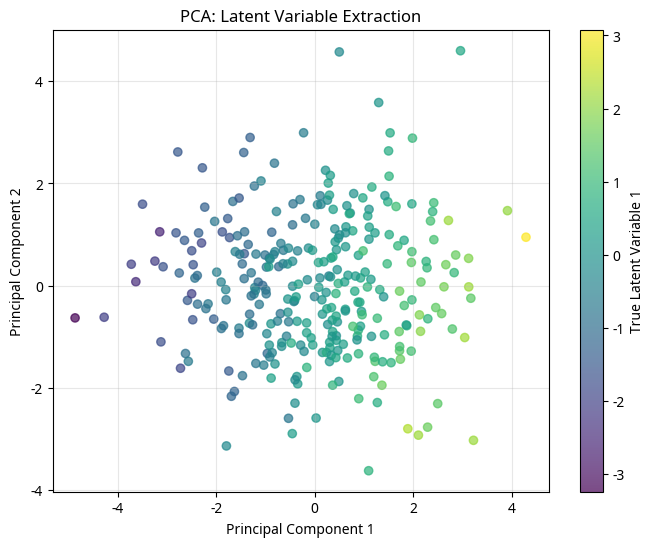

In [2]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Reduced data shape: {X_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {np.sum(pca.explained_variance_ratio_):.2f}")

# Plot the latent representation
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, c=latent_vars[:, 0], cmap='viridis')
plt.colorbar(label='True Latent Variable 1')
plt.title('PCA: Latent Variable Extraction')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.show()

### 1.3 Representation and Reconstruction

We can reconstruct the original 5-dimensional data from the 2-dimensional PCA representation.

In [3]:
# Reconstruct the data
X_reconstructed = pca.inverse_transform(X_pca)

# Calculate reconstruction error (Mean Squared Error)
mse = np.mean((X_scaled - X_reconstructed) ** 2)
print(f"Reconstruction Mean Squared Error: {mse:.4f}")

Reconstruction Mean Squared Error: 0.1644


### Reflection Questions (Part 1)
1. Look at the explained variance ratio. Why do the first two components capture the majority of the variance in this specific dataset?
2. If we used `n_components=5`, what would the reconstruction error be? Why?

---

## Part 2: Sparse PCA (Disentangling Features)

Standard PCA creates principal components that are linear combinations of *all* original features. This makes interpretation difficult, especially in high-dimensional settings (e.g., genomics or text data), because the components do not cleanly "disentangle" the features.

Sparse PCA adds an L1 penalty (Lasso) to the component weights, forcing many weights to become exactly zero. This results in components that depend on only a small subset of features, making them highly interpretable.

### 2.1 The Problem with Standard PCA Loadings

Let's look at the weights (loadings) of the standard PCA we just ran.

In [4]:
# Display standard PCA components
df_pca = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=[f'Feature {i+1}' for i in range(5)]
)
print("Standard PCA Loadings:")
print(df_pca.round(3))

Standard PCA Loadings:
             PC1    PC2
Feature 1  0.583 -0.049
Feature 2  0.564  0.002
Feature 3  0.542 -0.216
Feature 4 -0.004  0.715
Feature 5  0.222  0.663


Notice that all features contribute to both PC1 and PC2. It is hard to say "PC1 represents features 1-3" cleanly.

### 2.2 Applying Sparse PCA

Now, let's apply Sparse PCA to the same data.

In [5]:
from sklearn.decomposition import SparsePCA

# Apply Sparse PCA
# alpha controls the sparsity (higher alpha = more sparse)
spca = SparsePCA(n_components=2, alpha=1.5, random_state=42)
X_spca = spca.fit_transform(X_scaled)

# Display Sparse PCA components
df_spca = pd.DataFrame(
    spca.components_.T, 
    columns=['SPC1', 'SPC2'], 
    index=[f'Feature {i+1}' for i in range(5)]
)
print("\nSparse PCA Loadings:")
print(df_spca.round(3))


Sparse PCA Loadings:
            SPC1   SPC2
Feature 1  0.592  0.000
Feature 2  0.567  0.000
Feature 3  0.558 -0.096
Feature 4  0.000  0.722
Feature 5  0.132  0.686


Notice how Sparse PCA has forced several weights to exactly zero. SPC1 is now driven almost entirely by Features 1, 2, and 3, while SPC2 is driven by Features 4 and 5. This perfectly disentangles the underlying structure we created in Section 1.1!

### Reflection Questions (Part 2)
1. Compare the standard PCA loadings with the Sparse PCA loadings. How does sparsity improve the interpretability of the latent variables?
2. What is the trade-off of using Sparse PCA? (Hint: Think about the total explained variance and orthogonality of the components).

---

## Part 3: Kernel PCA (Non-Linear Dimension Reduction)

Standard PCA assumes that the data lies on a linear subspace. If the data has a non-linear structure (e.g., concentric circles or a Swiss roll), standard PCA will fail to capture the underlying manifold.

Kernel PCA uses the "kernel trick" to implicitly map the data into a high-dimensional feature space where it becomes linearly separable, and then performs PCA in that space.

### 3.1 A Non-Linear Dataset (Concentric Circles)

Let's generate a dataset of two concentric circles.

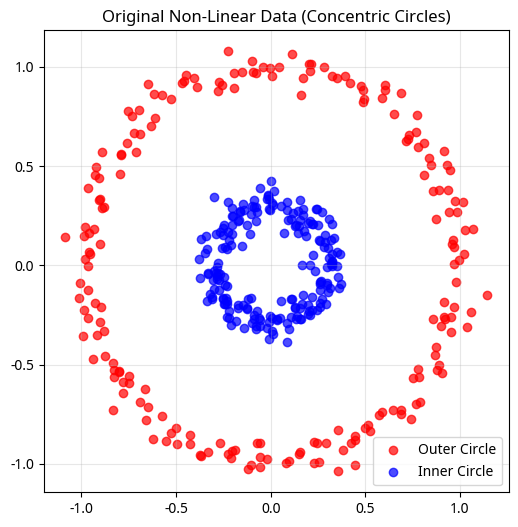

In [6]:
from sklearn.datasets import make_circles

# Generate concentric circles
X_circles, y_circles = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(X_circles[y_circles==0, 0], X_circles[y_circles==0, 1], color='red', alpha=0.7, label='Outer Circle')
plt.scatter(X_circles[y_circles==1, 0], X_circles[y_circles==1, 1], color='blue', alpha=0.7, label='Inner Circle')
plt.title('Original Non-Linear Data (Concentric Circles)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.2 Why Standard PCA Fails Here

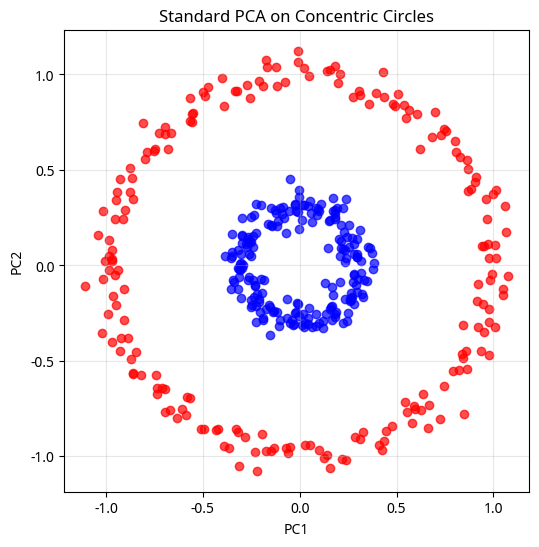

In [7]:
# Apply standard PCA
pca_linear = PCA(n_components=2)
X_pca_circles = pca_linear.fit_transform(X_circles)

plt.figure(figsize=(6, 6))
plt.scatter(X_pca_circles[y_circles==0, 0], X_pca_circles[y_circles==0, 1], color='red', alpha=0.7)
plt.scatter(X_pca_circles[y_circles==1, 0], X_pca_circles[y_circles==1, 1], color='blue', alpha=0.7)
plt.title('Standard PCA on Concentric Circles')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.show()

Standard PCA just rotates the data. The classes are still not linearly separable, and the non-linear structure is not "unrolled."

### 3.3 Applying Kernel PCA

We will use Kernel PCA with a Radial Basis Function (RBF) kernel.

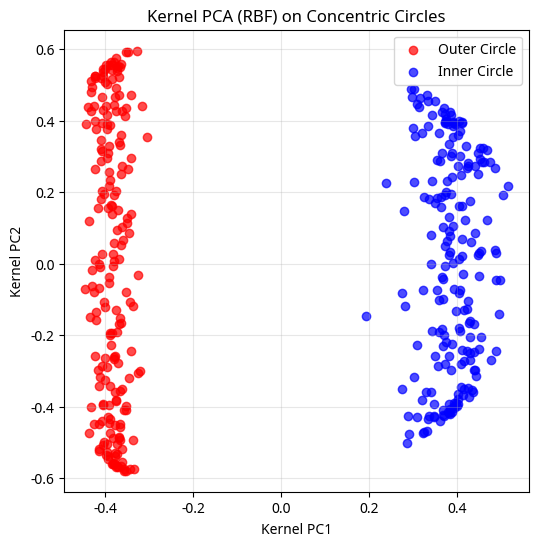

In [8]:
from sklearn.decomposition import KernelPCA

# Apply Kernel PCA with RBF kernel
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=2.0)
X_kpca = kpca.fit_transform(X_circles)

plt.figure(figsize=(6, 6))
plt.scatter(X_kpca[y_circles==0, 0], X_kpca[y_circles==0, 1], color='red', alpha=0.7, label='Outer Circle')
plt.scatter(X_kpca[y_circles==1, 0], X_kpca[y_circles==1, 1], color='blue', alpha=0.7, label='Inner Circle')
plt.title('Kernel PCA (RBF) on Concentric Circles')
plt.xlabel('Kernel PC1')
plt.ylabel('Kernel PC2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Notice how Kernel PCA has successfully separated the inner and outer circles into distinct regions in the latent space!

### Reflection Questions (Part 3)
1. Why did standard PCA fail to separate the concentric circles?
2. How does the `gamma` parameter in the RBF kernel affect the projection? (Try changing it to 0.1 or 10.0 and observe the results).

---

## Part 4: Probabilistic PCA (PPCA)

Standard PCA is a deterministic linear algebra operation. Probabilistic PCA (PPCA) formulates PCA as a generative latent variable model using Gaussian distributions. 

The PPCA model is:
$$ \mathbf{x} = \mathbf{W}\mathbf{z} + oldsymbol{\mu} + oldsymbol{\epsilon} $$
Where $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and $oldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \sigma^2\mathbf{I})$.

**Why use PPCA?**
1. It provides a principled way to handle **missing data** using the Expectation-Maximization (EM) algorithm.
2. It allows us to generate new, synthetic data samples from the learned distribution.

### 4.1 PPCA for Missing Data Imputation

While `scikit-learn`'s standard PCA uses SVD and cannot handle missing values (`NaN`), we can implement a simple PPCA using an iterative approach (or use specialized libraries) to impute missing data.

*Note: For this lab, we will use a conceptual demonstration of how PPCA handles missing data via iterative reconstruction.*

In [9]:
# Create a copy of our scaled data and introduce missing values
X_missing = X_scaled.copy()
np.random.seed(42)
# Randomly set 10% of the data to NaN
mask = np.random.rand(*X_missing.shape) < 0.10
X_missing[mask] = np.nan

print(f"Number of missing values: {np.isnan(X_missing).sum()}")

# Simple Iterative PCA (a simplified EM approach for PPCA)
def iterative_pca_impute(X, n_components=2, max_iter=50, tol=1e-4):
    # Initialize missing values with column means
    X_imputed = np.copy(X)
    col_means = np.nanmean(X_imputed, axis=0)
    inds = np.where(np.isnan(X_imputed))
    X_imputed[inds] = np.take(col_means, inds[1])
    
    pca = PCA(n_components=n_components)
    
    for i in range(max_iter):
        X_old = np.copy(X_imputed)
        
        # E-step: Project data to latent space
        Z = pca.fit_transform(X_imputed)
        
        # M-step: Reconstruct data
        X_rec = pca.inverse_transform(Z)
        
        # Update only the missing values
        X_imputed[inds] = X_rec[inds]
        
        # Check convergence
        diff = np.linalg.norm(X_imputed[inds] - X_old[inds])
        if diff < tol:
            print(f"Converged at iteration {i+1}")
            break
            
    return X_imputed

# Impute the missing data
X_imputed = iterative_pca_impute(X_missing, n_components=2)

# Calculate error only on the missing entries
true_missing_values = X_scaled[mask]
imputed_values = X_imputed[mask]
imputation_mse = np.mean((true_missing_values - imputed_values)**2)

print(f"Imputation Mean Squared Error: {imputation_mse:.4f}")

Number of missing values: 161
Imputation Mean Squared Error: 0.5374


### Reflection Questions (Part 4)
1. How does the probabilistic formulation of PCA (PPCA) allow for the Expectation-Maximization (EM) algorithm to handle missing data?
2. If the noise variance $\sigma^2$ in the PPCA model goes to zero, what does the model converge to?

---

## Part 5: Student Coding Exercise

Now it is your turn to apply these concepts to a real-world dataset. We will use the famous **Breast Cancer Wisconsin dataset**, which has 30 high-dimensional features.

**Your Task:**
1. Load and standardize the dataset.
2. Apply **Standard PCA** (2 components) and plot the result, coloring the points by their true class (Malignant vs. Benign).
3. Apply **Sparse PCA** (2 components). Examine the components (`components_`). How many features are exactly zero in the first sparse principal component?
4. Apply **Kernel PCA** (try both `poly` and `rbf` kernels) and plot the results. Does a non-linear kernel provide better visual separation of the classes than standard PCA for this specific dataset?

Write your code in the block below:

In [10]:
# --- STUDENT EXERCISE ---
from sklearn.datasets import load_breast_cancer

# 1. Load and standardize the data
data = load_breast_cancer()
X_cancer = data.data
y_cancer = data.target
feature_names = data.feature_names

# Write your code here:
# scaler = ...
# X_cancer_scaled = ...

# 2. Standard PCA
# ...

# 3. Sparse PCA
# ...

# 4. Kernel PCA
# ...
